Given the root of a binary tree, the depth of each node is the shortest distance to the root.

Return the smallest subtree such that it contains all the deepest nodes in the original tree.

A node is called the deepest if it has the largest depth possible among any node in the entire tree.

The subtree of a node is a tree consisting of that node, plus the set of all descendants of that node.

 

Example 1:

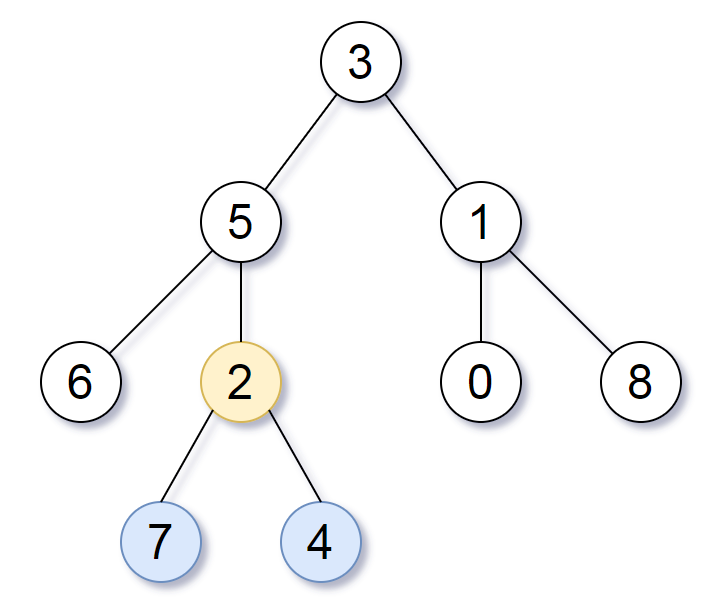

Input: root = [3,5,1,6,2,0,8,null,null,7,4]
Output: [2,7,4]
Explanation: We return the node with value 2, colored in yellow in the diagram.
The nodes coloured in blue are the deepest nodes of the tree.
Notice that nodes 5, 3 and 2 contain the deepest nodes in the tree but node 2 is the smallest subtree among them, so we return it.

Example 2:

Input: root = [1]
Output: [1]
Explanation: The root is the deepest node in the tree.

Example 3:

Input: root = [0,1,3,null,2]
Output: [2]
Explanation: The deepest node in the tree is 2, the valid subtrees are the subtrees of nodes 2, 1 and 0 but the subtree of node 2 is the smallest.

 

Constraints:

    The number of nodes in the tree will be in the range [1, 500].
    0 <= Node.val <= 500
    The values of the nodes in the tree are unique.

 

Note: This question is the same as 1123: https://leetcode.com/problems/lowest-common-ancestor-of-deepest-leaves/
 

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def subtreeWithAllDeepest(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        if root is None:
            return None
        self.deepest_paths = []
        self.max_lvl = -1

        def dfs(node, lvl, path):
            path.append(node)
            if not (node.right or node.left):
                if lvl > self.max_lvl:
                    self.max_lvl = lvl
                    self.deepest_paths = []
                if lvl == self.max_lvl:
                    self.deepest_paths.append(path.copy())
            if node.left:
                dfs(node.left, lvl + 1, path)
            if node.right:
                dfs(node.right, lvl + 1, path)
            path.pop()


        dfs(root, 0, [])

        while True:
            curr_anchestor = self.deepest_paths[0].pop()
            all_eq = True
            for path in self.deepest_paths[1:]:
                if path.pop() != curr_anchestor:
                    all_eq = False
            if all_eq:
                return curr_anchestor
        

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def subtreeWithAllDeepest(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        def dfs(root):
            if not root:
                return dict(depth=0, val=None)
            left = dfs(root.left)
            right = dfs(root.right)
            if left["depth"] > right["depth"]:
                return dict(depth=left["depth"] + 1, val=left["val"])
            elif left["depth"] < right["depth"]:
                return dict(depth=right["depth"] + 1, val=right["val"])
            else:
                return dict(depth=left["depth"] + 1, val=root)
        
        return dfs(root)["val"]